In [54]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
df = pd.read_parquet("data/base_ind_2025.parquet")

In [56]:
map_region = {
    1: "Gran Buenos Aires",
    40: "NOA",
    41: "NEA",
    42: "Cuyo",
    43: "Pampeana",
    44: "Patagonia"
}

df.REGION = df.REGION.map(map_region)

In [57]:
map_sexo = {
    1: "Varon",
    2: "Mujer"
}

df.CH04 = df.CH04.map(map_sexo)

In [58]:
map_nivel_ed = {
    1: "Primario Incompleto",
    2: "Primario Completo",
    3: "Secundario Incompleto",
    4: "Secundario Completo",
    5: "Superior o Universitario Incompleto",
    6: "Superior o Universitario Completo",
    7: "Sin Instruccion",
    9: "NS/NC"
}

df.NIVEL_ED = df.NIVEL_ED.map(map_nivel_ed)

In [59]:
df.NIVEL_ED.value_counts()

NIVEL_ED
Secundario Completo                    30750
Secundario Incompleto                  27966
Superior o Universitario Completo      19252
Primario Incompleto                    18306
Superior o Universitario Incompleto    17144
Primario Completo                      15152
Sin Instruccion                         7887
Name: count, dtype: int64

In [60]:
df.columns

Index(['CODUSU', 'NRO_HOGAR', 'COMPONENTE', 'ANO4', 'TRIMESTRE', 'REGION',
       'PONDERA', 'PONDII', 'PONDIIO', 'CH04', 'CH06', 'NIVEL_ED', 'ESTADO',
       'CAT_OCUP', 'CAT_INAC', 'EMPLEO', 'P21', 'P47T', 'PP04B_COD',
       'PP04D_COD', 'caes_version', 'PP04B_label', 'caes_seccion_cod',
       'caes_seccion_label', 'caes_division_cod', 'caes_division_label',
       'caes_eph_cod', 'caes_eph_label', 'CATEGORIA', 'JERARQUIA',
       'TECNOLOGIA', 'CALIFICACION'],
      dtype='str')

In [61]:
map_estado = {
    0: "Sin respuesta",
    1: "Ocupado",
    2: "Desocupado",
    3: "Inactivo",
    4: "Menor de 10 años"
}

df.ESTADO = df.ESTADO.map(map_estado)

In [62]:
df.ESTADO.value_counts()

ESTADO
Ocupado             60516
Inactivo            56689
Menor de 10 años    14989
Desocupado           4071
Sin respuesta         192
Name: count, dtype: int64

In [63]:
map_cat_ocup = {
    0: "Inactivo",
    1: "Patron",
    2: "Cuenta Propia",
    3: "Obrero o empleado",
    4: "Trabajador familiar sin remuneracion",
    9: "NS/NR"
}

df.CAT_OCUP = df.CAT_OCUP.map(map_cat_ocup)
df.CAT_OCUP.value_counts()

CAT_OCUP
Inactivo                                72854
Obrero o empleado                       46203
Cuenta Propia                           15003
Patron                                   2123
Trabajador familiar sin remuneracion      269
NS/NR                                       5
Name: count, dtype: int64

In [64]:
map_cat_inac = {
    0: "Ocupado",
    1: "Jubilado",
    2: "Rentista",
    3: "Estudiante",
    4: "Ama de Casa",
    5: "Menor de 6 años",
    6: "Discapacitado",
    7: "Otros"
}

df.CAT_INAC = df.CAT_INAC.map(map_cat_inac)
df.CAT_INAC.value_counts()

CAT_INAC
Ocupado            64780
Estudiante         31845
Jubilado           14361
Ama de Casa        13235
Menor de 6 años     7325
Otros               3111
Discapacitado       1503
Rentista             297
Name: count, dtype: int64

In [65]:
df.P47T = df.P47T.replace(-9, np.nan)

In [66]:
map_empleo = {
    1: "Formal",
    2: "Informal",
    9: "NS/NR"
}

df.EMPLEO = df.EMPLEO.map(map_empleo)
df.EMPLEO.value_counts()

EMPLEO
Formal      33910
Informal    26561
NS/NR          45
Name: count, dtype: int64

In [67]:
df_select = df[
    [
        "CODUSU",
        "NRO_HOGAR",
        "COMPONENTE",
        "ANO4",
        "TRIMESTRE",
        "REGION",
        "PONDERA",
        "PONDII",
        "PONDIIO",
        "CH04",
        "CH06",
        "NIVEL_ED",
        "ESTADO",
        "CAT_OCUP",
        "CAT_INAC",
        "EMPLEO",
        "P21",
        "P47T",
        "caes_seccion_label",
        "JERARQUIA",
    ]
]

In [68]:
df_select["situacion_ocupacional"] = np.where(df_select.CAT_INAC == "Ocupado", df_select.CAT_OCUP, df_select.CAT_INAC)

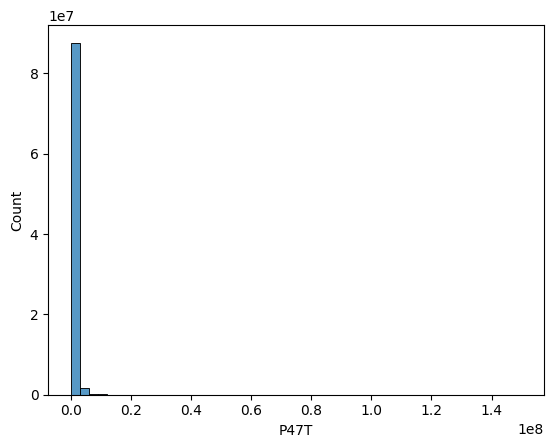

In [69]:
sns.histplot(
    data=df_select,
    x="P47T",
    weights="PONDII",
    bins=50
)
plt.show()

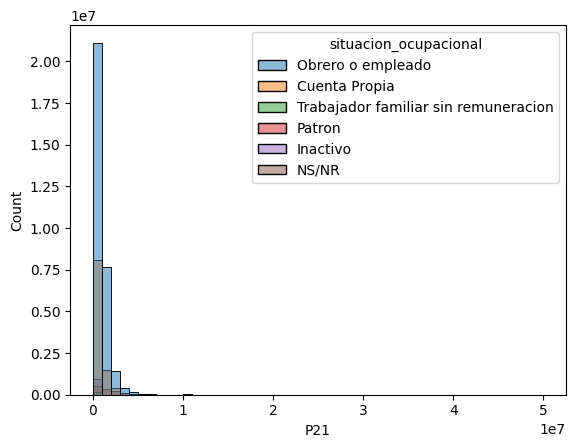

In [70]:
# histoplot de P21 ponderado con PONDIIO, coloreado por situacion_ocupacional, cuando CAT_INAC = "Ocupado"
sns.histplot(
    data=df_select[df_select.CAT_INAC == "Ocupado"],
    x="P21",
    weights="PONDII",
    bins=50,
    hue="situacion_ocupacional"
)
plt.show()

In [71]:
df_select.situacion_ocupacional.value_counts()

# value_counts de situacion_ocupacional, ponderado por PONDERA y separado por trimestre
for trimestre in df_select.TRIMESTRE.unique():
    print(f"Trimestre {trimestre}")
    # print(df_select[df_select.TRIMESTRE == trimestre].situacion_ocupacional.value_counts(normalize=True, weights=df_select[df_select.TRIMESTRE == trimestre].PONDERA))
    # Lo de arriba da error: TypeError: IndexOpsMixin.value_counts() got an unexpected keyword argument 'weights', alternativa con groupby y sum, MOSTRANDO TOTALES, NO PROPORCIONES:
    print(df_select[df_select.TRIMESTRE == trimestre].groupby("situacion_ocupacional")["PONDERA"].sum().sort_values(ascending=False))


Trimestre 1
situacion_ocupacional
Obrero o empleado                       10286479
Estudiante                               7301917
Cuenta Propia                            3318224
Ama de Casa                              2737191
Jubilado                                 2591502
Menor de 6 años                          1829419
Otros                                     582078
Patron                                    458764
Inactivo                                  321435
Discapacitado                             281164
Rentista                                   71186
Trabajador familiar sin remuneracion       59956
NS/NR                                       7863
Name: PONDERA, dtype: int32
Trimestre 2
situacion_ocupacional
Obrero o empleado                       10280725
Estudiante                               7394317
Cuenta Propia                            3366484
Ama de Casa                              2613251
Jubilado                                 2576192
Menor de 6 años       

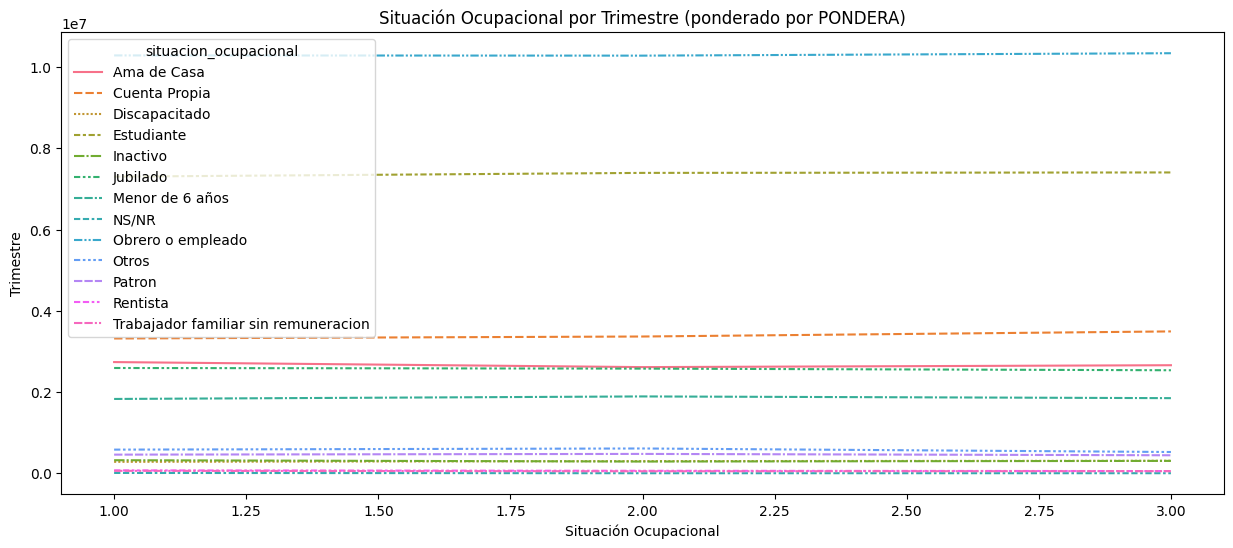

In [72]:
plt.figure(figsize=(15, 6))
data = pd.pivot_table(
    df_select,
    index="situacion_ocupacional",
    columns="TRIMESTRE",
    values="PONDERA",
    aggfunc="sum"
).T
sns.lineplot(data=data)
plt.title("Situación Ocupacional por Trimestre (ponderado por PONDERA)")
plt.xlabel("Situación Ocupacional")
plt.ylabel("Trimestre")
plt.show()

<Axes: xlabel='TRIMESTRE'>

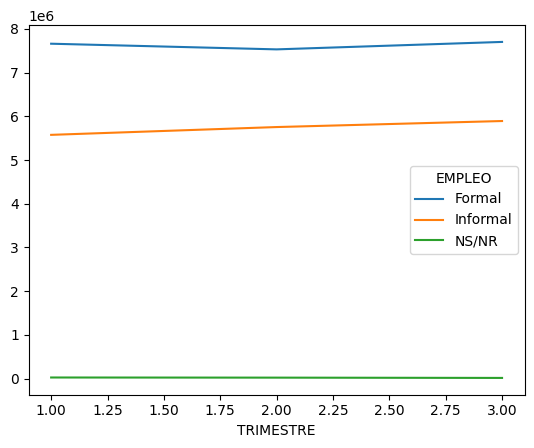

In [73]:
pd.pivot_table(
    df_select,
    index="EMPLEO",
    columns="TRIMESTRE",
    values="PONDERA",
    aggfunc="sum"
).T.plot()

<Axes: xlabel='TRIMESTRE'>

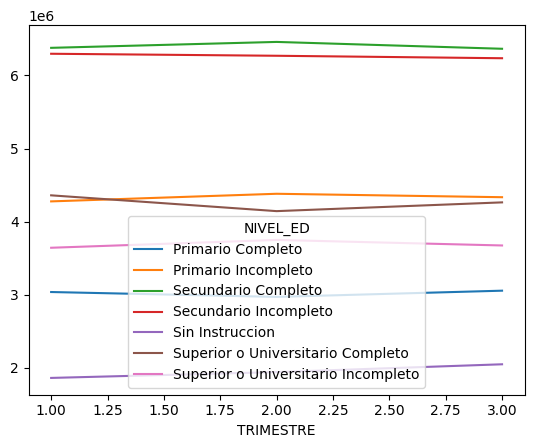

In [74]:
pd.pivot_table(
    df_select,
    index="NIVEL_ED",
    columns="TRIMESTRE",
    values="PONDERA",
    aggfunc="sum"
).T.plot()